In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
pranaykoppula_torgo_audio_path = kagglehub.dataset_download('pranaykoppula/torgo-audio')

print('Data source import complete.')


100%|██████████| 1.29G/1.29G [00:12<00:00, 113MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import warnings
from sklearn.utils import resample

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
class AudioDataset(Dataset):
    def __init__(self, audio_files, labels, processor, max_length=16000*3):
        self.audio_files = audio_files
        self.labels = labels
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        audio_file = self.audio_files[idx]

        # Load and preprocess audio
        waveform, sr = librosa.load(audio_file, sr=16000)

        # Pad or truncate to max_length
        if len(waveform) > self.max_length:
            waveform = waveform[:self.max_length]
        else:
            padding = self.max_length - len(waveform)
            waveform = np.pad(waveform, (0, padding))

        # Process with wav2vec2
        inputs = self.processor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            padding="max_length",
            max_length=self.max_length
        )

        return {
            'input_values': inputs.input_values.squeeze(),
            'label': torch.tensor(1 if self.labels[idx] == 'Dysarthric' else 0)
        }


In [ ]:
class SpeechClassifier(nn.Module):
    def __init__(self, hidden_size=768, num_classes=2):
        super().__init__()

        self.wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

# 1. Freeze the Feature Extractor (the raw audio processor)
        self.wav2vec2.feature_extractor._freeze_parameters()

# 2. Unfreeze the Encoder (the top layers)
# allow the model to learn "Dysarthric" context
        for param in self.wav2vec2.encoder.parameters():
            param.requires_grad = True

        self.conv_layers = nn.Sequential(
            nn.Conv1d(hidden_size, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Conv1d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, num_classes)
        )

    def forward(self, input_values):
        outputs = self.wav2vec2(input_values)
        hidden_states = outputs.last_hidden_state

        x = hidden_states.transpose(1, 2)
        x = self.conv_layers(x)
        x = x.transpose(1, 2)
        x = self.transformer(x)
        x = torch.mean(x, dim=1)
        x = self.classifier(x)

        return x

In [ ]:
def load_and_sample_audio_files(base_path, sample_size=4000):
    """Load and sample audio files from TORGO dataset directories"""
    audio_files = []
    labels = []

    subdirs = ['F_Con', 'F_Dys', 'M_Con', 'M_Dys']

    # First collect all files
    for subdir in tqdm(subdirs, desc="Collecting files"):
        current_path = os.path.join(base_path, subdir)
        label = 'Dysarthric' if 'Dys' in subdir else 'Control'

        for root, dirs, files in os.walk(current_path):
            for file in files:
                if file.endswith('.wav'):
                    file_path = os.path.join(root, file)
                    audio_files.append(file_path)
                    labels.append(label)

    # Convert to DataFrame for easier sampling
    df = pd.DataFrame({'file': audio_files, 'label': labels})

    # Separate by class
    control_df = df[df['label'] == 'Control']
    dysarthric_df = df[df['label'] == 'Dysarthric']

    # Calculate samples per class (balanced)
    samples_per_class = min(sample_size // 2, len(control_df), len(dysarthric_df))

    # Sample equally from each class
    control_sample = control_df.sample(n=samples_per_class, random_state=42)
    dysarthric_sample = dysarthric_df.sample(n=samples_per_class, random_state=42)

    # Combine samples
    final_df = pd.concat([control_sample, dysarthric_sample])
    final_df = final_df.sample(frac=1, random_state=42)  # Shuffle

    print(f"Total samples: {len(final_df)}")
    print(f"Control samples: {len(control_sample)}")
    print(f"Dysarthric samples: {len(dysarthric_sample)}")

    return final_df['file'].tolist(), final_df['label'].tolist()

In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            input_values = batch['input_values'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_values)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                input_values = batch['input_values'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_values)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        print(f'Epoch {epoch+1}:')
        print(f'Training Loss: {train_loss:.4f}')
        print(f'Validation Loss: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')

    return all_preds, all_labels

In [ ]:
def plot_confusion_matrix(conf_matrix):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d',
                xticklabels=['Control', 'Dysarthric'],
                yticklabels=['Control', 'Dysarthric'],
                cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [ ]:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

Using device: cuda


In [ ]:
    print("Loading and sampling audio files...")
    audio_files, labels = load_and_sample_audio_files(pranaykoppula_torgo_audio_path, sample_size=4000)

Loading and sampling audio files...


Total samples: 4000
Control samples: 2000
Dysarthric samples: 2000


In [ ]:
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

In [ ]:
    dataset = AudioDataset(audio_files, labels, processor)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])


In [ ]:
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


In [ ]:
    model = SpeechClassifier().to(device)


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
    print("\nTraining model...")
    predictions, true_labels = train_model(model, train_loader, val_loader, device, epochs=2)



Training model...


Epoch 1/2: 100%|██████████| 200/200 [02:44<00:00,  1.22it/s]


Epoch 1:
Training Loss: 0.3668
Validation Loss: 1.0235


Epoch 2/2: 100%|██████████| 200/200 [02:36<00:00,  1.28it/s]


Epoch 2:
Training Loss: 0.1941
Validation Loss: 0.1511


In [ ]:
    print("\nClassification Report:")
    print(classification_report(true_labels, predictions,
                              target_names=['Control', 'Dysarthric']))


Classification Report:
              precision    recall  f1-score   support

     Control       0.93      0.99      0.96       406
  Dysarthric       0.99      0.93      0.96       394

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



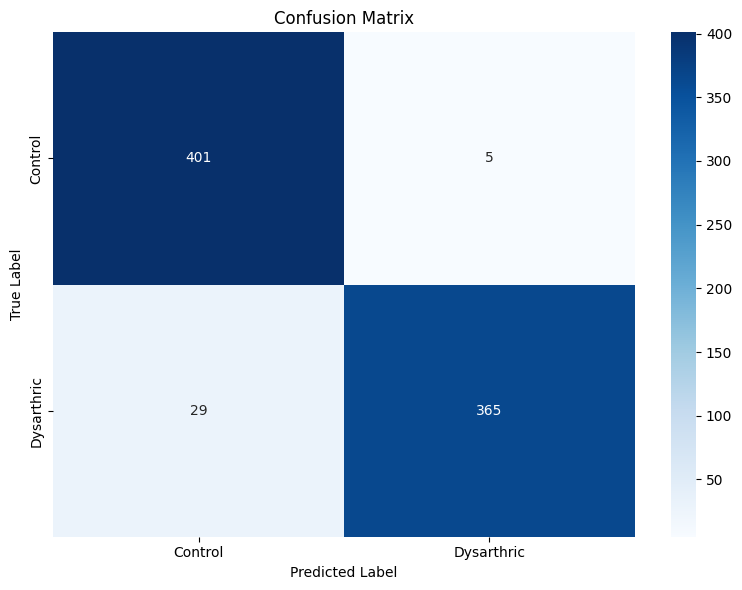

In [ ]:
    conf_matrix = confusion_matrix(true_labels, predictions)
    plot_confusion_matrix(conf_matrix)